# Fase 3: Análisis Diferencial y Validación Agronómica de Clústeres

**Project Terra** — Caracterización del perfil ambiental de cada clúster y contraste con el cultivo real reportado en cada registro.

En este notebook, a partir de los clústeres obtenidos en `03_clustering.ipynb`, realizamos:
- Estadísticos descriptivos por clúster.
- Boxplots paralelos y radar chart del perfil ambiental de cada clúster.
- Validación agronómica contra el cultivo real (`Crop`).
- Pruebas estadísticas (ANOVA / Kruskal-Wallis) para confirmar diferencias significativas entre clústeres.

> Requiere que `03_clustering.ipynb` se haya ejecutado previamente para generar `data/processed/sensor_Crop_Dataset_clustered.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from math import pi

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Carga de Datos con Clústeres Asignados

In [2]:
clustered_path = "../data/processed/sensor_Crop_Dataset_clustered.csv"
df = pd.read_csv(clustered_path)

cluster_col = 'cluster_kmeans'  # cambiar a 'cluster_hierarchical' para comparar con el otro método
target = 'Crop'

feature_cols = [c for c in df.select_dtypes(include=np.number).columns if not c.startswith('cluster')]

# Nombres legibles de las columnas, para usar en títulos y ejes de los gráficos
nombres_legibles = {
    'Nitrogen': 'Nitrógeno',
    'Phosphorus': 'Fósforo',
    'Potassium': 'Potasio',
    'Temperature': 'Temperatura',
    'Humidity': 'Humedad',
    'pH_Value': 'Valor del pH',
    'Rainfall': 'Precipitación',
}

print(f"Dimensiones: {df.shape}")
df.head()

Dimensiones: (20000, 10)


,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop,cluster_kmeans,cluster_hierarchical
0,-0.194526,0.263243,1.267102,-1.014884,0.398209,-1.613560,0.835917,Wheat,2,0
1,0.719418,0.920005,-0.888844,-0.556909,1.706133,-1.500767,-1.061136,Tomato,0,3
2,1.276206,0.802154,-1.034668,0.582042,0.822224,0.060466,-1.162575,Sugarcane,0,2
3,-1.482386,1.627335,-1.572150,-1.301155,-0.278378,-0.172904,-1.636999,Sugarcane,2,3
4,-1.322013,1.699590,-0.628804,-1.063698,-0.678517,1.533371,0.766203,Maize,1,0


## 2. Estadísticos Descriptivos por Clúster

In [3]:
cluster_summary = df.groupby(cluster_col)[feature_cols].agg(['mean', 'std']).round(2)
cluster_summary

Nitrogen       Phosphorus       Potassium       Temperature  \
                   mean   std       mean   std      mean   std        mean   
cluster_kmeans                                                               
0                  0.82  0.58       0.97  0.49      0.05  1.00        0.01   
1                 -0.81  0.59       0.06  0.91     -0.03  1.00        0.04   
2                 -0.83  0.57      -0.05  0.92      0.05  1.00       -0.04   
3                  0.81  0.57      -0.94  0.50     -0.06  0.99       -0.01   

                     Humidity       pH_Value       Rainfall        
                 std     mean   std     mean   std     mean   std  
cluster_kmeans                                                     
0               0.99     0.05  1.01    -0.04  0.92    -0.03  0.99  
1               1.01    -0.06  0.99     0.95  0.50     0.03  1.01  
2               1.01     0.05  0.99    -0.95  0.49    -0.02  0.99  
3               0.99    -0.03  1.00     0.03  0.93     0.01  1.01

In [4]:
df[cluster_col].value_counts().sort_index().rename('n_registros')

cluster_kmeans
0    4947
1    5020
2    4964
3    5069
Name: n_registros, dtype: int64

## 3. Boxplots Paralelos por Variable
Comparamos la distribución de cada variable ambiental entre clústeres.

C:\Users\carli\AppData\Local\Temp\ipykernel_9912\3930577346.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=cluster_col, y=col, ax=axes[i], palette='viridis')
C:\Users\carli\AppData\Local\Temp\ipykernel_9912\3930577346.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=cluster_col, y=col, ax=axes[i], palette='viridis')


C:\Users\carli\AppData\Local\Temp\ipykernel_9912\3930577346.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=cluster_col, y=col, ax=axes[i], palette='viridis')
C:\Users\carli\AppData\Local\Temp\ipykernel_9912\3930577346.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=cluster_col, y=col, ax=axes[i], palette='viridis')


C:\Users\carli\AppData\Local\Temp\ipykernel_9912\3930577346.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=cluster_col, y=col, ax=axes[i], palette='viridis')
C:\Users\carli\AppData\Local\Temp\ipykernel_9912\3930577346.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=cluster_col, y=col, ax=axes[i], palette='viridis')


C:\Users\carli\AppData\Local\Temp\ipykernel_9912\3930577346.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=cluster_col, y=col, ax=axes[i], palette='viridis')


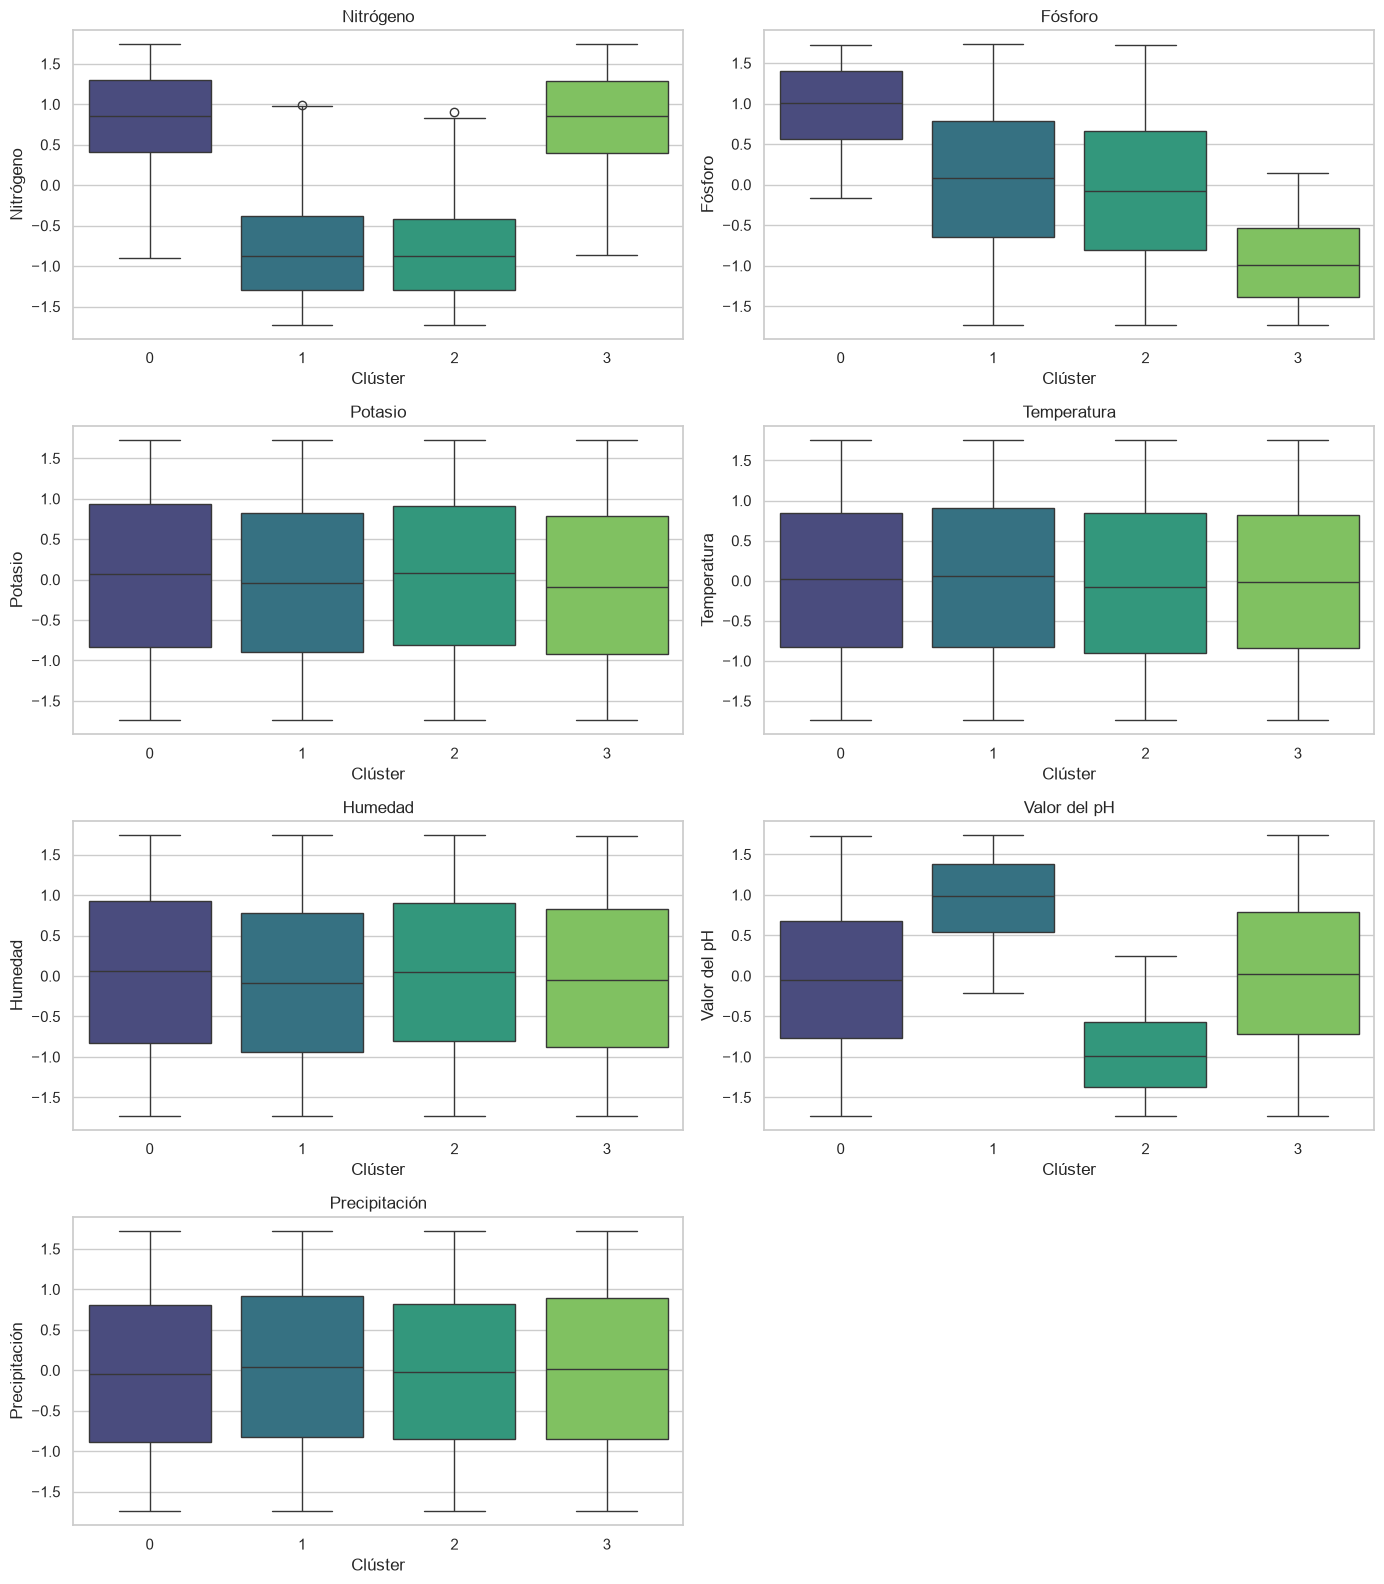

In [5]:
fig, axes = plt.subplots(nrows=(len(feature_cols) + 1) // 2, ncols=2, figsize=(14, 4 * ((len(feature_cols) + 1) // 2)))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.boxplot(data=df, x=cluster_col, y=col, ax=axes[i], palette='viridis')
    axes[i].set_title(nombres_legibles[col])
    axes[i].set_xlabel('Clúster')
    axes[i].set_ylabel(nombres_legibles[col])

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 4. Radar Chart — Firma Ambiental de cada Clúster
Normalizamos las medias de cada variable a una escala 0-1 para poder compararlas en un mismo radar.

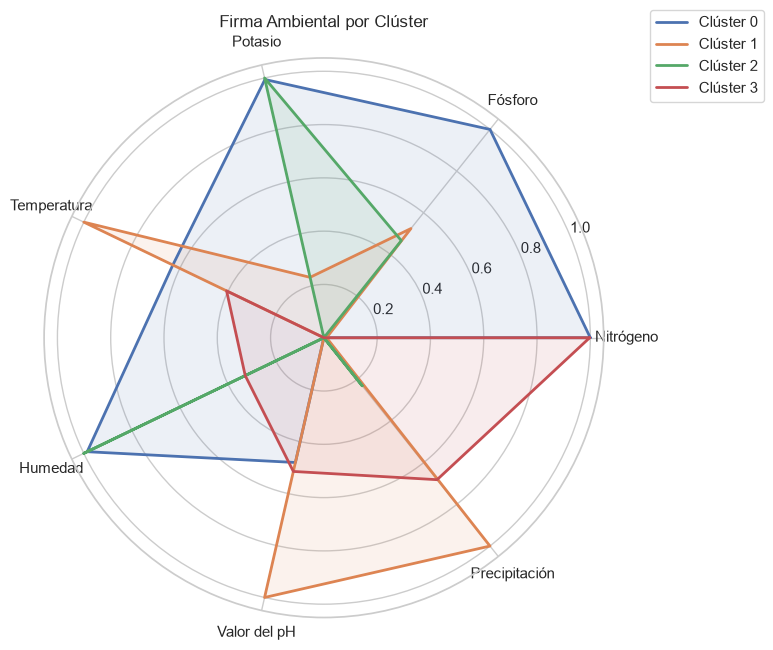

In [6]:
cluster_means = df.groupby(cluster_col)[feature_cols].mean()
cluster_means_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

categories = [nombres_legibles[c] for c in feature_cols]
n_vars = len(categories)
angles = [n / float(n_vars) * 2 * pi for n in range(n_vars)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for cluster_id, row in cluster_means_norm.iterrows():
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=f'Clúster {cluster_id}')
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_title('Firma Ambiental por Clúster')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

## 5. Validación Agronómica: Clúster vs. Cultivo Real
Contrastamos los clústeres obtenidos (basados solo en variables de suelo/clima) contra el cultivo realmente reportado en cada registro.

In [7]:
crosstab = pd.crosstab(df[cluster_col], df[target])
crosstab

Crop,Maize,Potato,Rice,Sugarcane,Tomato,Wheat
cluster_kmeans,,,,,,
0,827,798,801,794,792,935
1,840,894,852,828,845,761
2,790,864,826,788,844,852
3,895,806,789,874,863,842


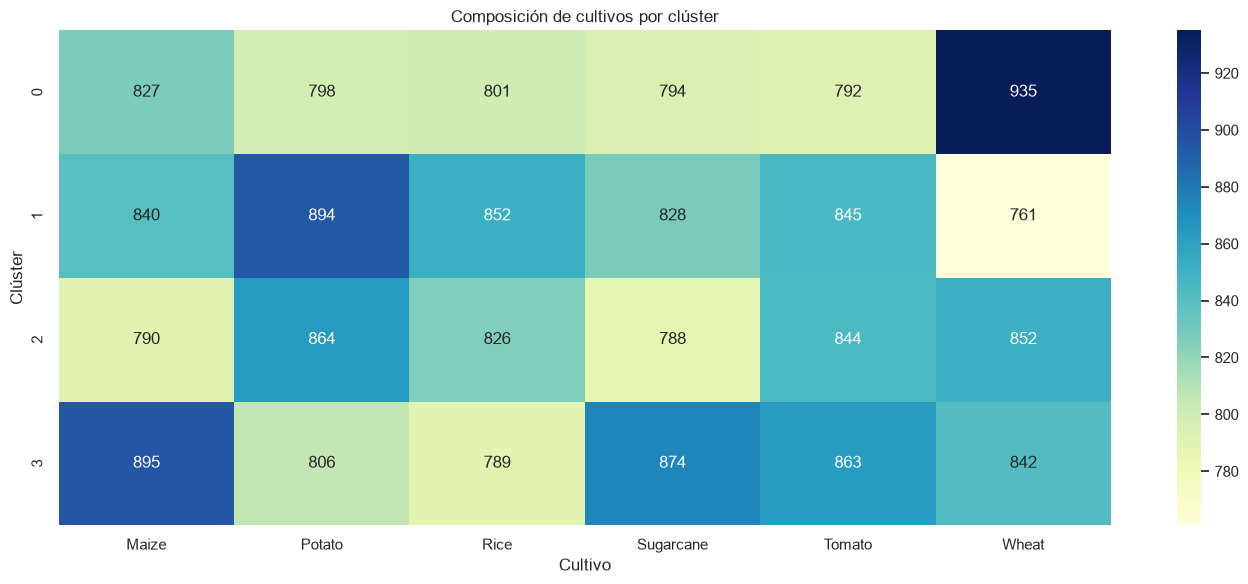

In [8]:
plt.figure(figsize=(14, 6))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Composición de cultivos por clúster')
plt.xlabel('Cultivo')
plt.ylabel('Clúster')
plt.tight_layout()
plt.show()

In [9]:
# Cultivo dominante (mayor proporción) en cada clúster
crosstab_share = crosstab.div(crosstab.sum(axis=1), axis=0)
dominant_crop = crosstab_share.idxmax(axis=1)
dominant_share = crosstab_share.max(axis=1)

pd.DataFrame({'cultivo_dominante': dominant_crop, 'proporcion': dominant_share.round(3)})

,cultivo_dominante,proporcion
cluster_kmeans,,
0,Wheat,0.189
1,Potato,0.178
2,Potato,0.174
3,Maize,0.177


## 6. Pruebas Estadísticas: ANOVA / Kruskal-Wallis
Verificamos si las diferencias de medias observadas entre clústeres son estadísticamente significativas para cada variable.

In [10]:
results = []

for col in feature_cols:
    groups = [group[col].values for _, group in df.groupby(cluster_col)]
    f_stat, p_anova = stats.f_oneway(*groups)
    h_stat, p_kruskal = stats.kruskal(*groups)
    results.append({
        'variable': col,
        'ANOVA_F': round(f_stat, 3),
        'ANOVA_p': p_anova,
        'Kruskal_H': round(h_stat, 3),
        'Kruskal_p': p_kruskal
    })

results_df = pd.DataFrame(results).sort_values('ANOVA_p')
results_df

,variable,ANOVA_F,ANOVA_p,Kruskal_H,Kruskal_p
0,Nitrogen,13349.284,0.000000e+00,13329.845,0.000000e+00
1,Phosphorus,5636.810,0.000000e+00,9171.107,0.000000e+00
5,pH_Value,5458.685,0.000000e+00,8990.881,0.000000e+00
4,Humidity,15.059,8.700303e-10,45.050,9.029135e-10
2,Potassium,14.939,1.036327e-09,44.733,1.054248e-09
3,Temperature,5.362,1.091404e-03,16.097,1.083180e-03
6,Rainfall,4.402,4.217298e-03,13.291,4.047362e-03


In [11]:
significativas = results_df[results_df['ANOVA_p'] < 0.05]
print(f"Variables con diferencias significativas entre clústeres (p < 0.05): {len(significativas)} de {len(results_df)}")
significativas

Variables con diferencias significativas entre clústeres (p < 0.05): 7 de 7


,variable,ANOVA_F,ANOVA_p,Kruskal_H,Kruskal_p
0,Nitrogen,13349.284,0.000000e+00,13329.845,0.000000e+00
1,Phosphorus,5636.810,0.000000e+00,9171.107,0.000000e+00
5,pH_Value,5458.685,0.000000e+00,8990.881,0.000000e+00
4,Humidity,15.059,8.700303e-10,45.050,9.029135e-10
2,Potassium,14.939,1.036327e-09,44.733,1.054248e-09
3,Temperature,5.362,1.091404e-03,16.097,1.083180e-03
6,Rainfall,4.402,4.217298e-03,13.291,4.047362e-03


## 7. Conclusiones preliminares

- **Perfiles diferenciados**: el radar chart y las medias por clúster muestran que la segmentación de K-Means se explica casi en su totalidad por `Nitrogen`, `Phosphorus` y `pH_Value`; `Potassium`, `Temperature`, `Humidity` y `Rainfall` varían muy poco entre clústeres. En términos prácticos: Clúster 0 = N y P altos, pH promedio; Clúster 1 = N bajo, pH alto; Clúster 2 = N bajo, pH bajo; Clúster 3 = N alto, P bajo, pH promedio.
- **Coherencia agronómica**: el cultivo dominante por clúster (Wheat 18.9%, Potato 17.8%, Potato 17.4%, Maize 17.7%) apenas supera la proporción de esos mismos cultivos en el dataset completo (~16-17%, ver EDA en `01_eda_crops_npk.ipynb`). Es decir, los clústeres **no** concentran un cultivo específico de forma marcada: la segmentación basada en N/P/K/pH/clima no reproduce bien las etiquetas de cultivo real.
- **Significancia estadística**: las 7 variables tienen p < 0.05 en ANOVA y Kruskal-Wallis, pero el tamaño de muestra (20,000 registros) hace que hasta diferencias mínimas resulten 'significativas'. Los F-estadísticos revelan la jerarquía real de importancia: `Nitrogen` (F=13,349), `Phosphorus` (F=5,637) y `pH_Value` (F=5,459) dominan la separación, mientras que `Humidity`, `Potassium`, `Temperature` y `Rainfall` tienen F mucho menores (5–15) y aportan poco a la partición pese a ser 'significativos'.
- **Conclusión general**: con K=4 y estas variables, K-Means produce una partición estadísticamente diferenciable pero agronómicamente débil (baja pureza de cultivo por clúster, acuerdo casi nulo con el clustering jerárquico, silueta baja). Esto sugiere explorar alternativas: usar solo el subconjunto de variables con mayor poder discriminante, incorporar `Soil_Type`/`Variety` como variables adicionales, o replantear el número de clústeres.
- **Siguiente paso**: usar estos perfiles en `05_dashboard.ipynb` para construir el tablero interpretativo final.